# 📝 Week 2: Stemming pada Teks

Notebook ini mendemonstrasikan teknik **stemming** untuk teks bahasa Inggris dan bahasa Indonesia dengan contoh yang lebih jelas dan output yang mudah dibaca.

## Tujuan Pembelajaran:
1. Memahami konsep stemming dan manfaatnya dalam NLP
2. Membandingkan hasil Porter Stemmer dan Lancaster Stemmer (bahasa Inggris)
3. Menerapkan Sastrawi Stemmer untuk bahasa Indonesia
4. Menganalisis dampak stemming terhadap variasi kata

## 📚 Konsep Singkat

**Stemming** adalah proses mengubah kata ke bentuk dasarnya (stem).

Contoh:
- `running`, `runs`, `runner` -> `run` (kurang lebih)
- `berlari`, `pelari`, `lari-larian` -> `lari` (bergantung stemmer)

Stemming sering digunakan sebelum klasifikasi sentimen, topic modeling, dan information retrieval.

In [6]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, LancasterStemmer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('✅ Library siap digunakan')

✅ Library siap digunakan


## 1) Contoh Bahasa Inggris: Porter vs Lancaster

Lancaster biasanya lebih agresif daripada Porter, sehingga hasil stem bisa lebih pendek.

In [7]:
english_text = "The researchers were running experiments, analyzed results, and writing reports beautifully."
tokens_en = [t for t in word_tokenize(english_text) if re.match(r'^[A-Za-z]+$', t)]

porter = PorterStemmer()
lancaster = LancasterStemmer()

porter_stems = [porter.stem(w.lower()) for w in tokens_en]
lancaster_stems = [lancaster.stem(w.lower()) for w in tokens_en]

df_en = pd.DataFrame({
    'original': [w.lower() for w in tokens_en],
    'porter': porter_stems,
    'lancaster': lancaster_stems
})

print('📄 Teks asli:')
print(english_text)
print('\n🔤 Token:')
print(tokens_en)
print('\n📊 Perbandingan hasil stemming (Inggris):')
display(df_en)

📄 Teks asli:
The researchers were running experiments, analyzed results, and writing reports beautifully.

🔤 Token:
['The', 'researchers', 'were', 'running', 'experiments', 'analyzed', 'results', 'and', 'writing', 'reports', 'beautifully']

📊 Perbandingan hasil stemming (Inggris):


,original,porter,lancaster
0,the,the,the
1,researchers,research,research
2,were,were,wer
3,running,run,run
4,experiments,experi,expery
5,analyzed,analyz,analys
6,results,result,result
7,and,and,and
8,writing,write,writ
9,reports,report,report


## 2) Contoh Bahasa Indonesia: Sastrawi Stemmer

Sastrawi dirancang khusus untuk morfologi bahasa Indonesia.

In [8]:
indonesian_text = "Para pengguna mengeluhkan keterlambatan pelayanan, kemudian petugas memperbaiki sistem pendaftaran."
tokens_id = [t for t in word_tokenize(indonesian_text) if re.match(r'^[A-Za-z]+$', t)]

stemmer_id = StemmerFactory().create_stemmer()
sastrawi_stems = [stemmer_id.stem(w.lower()) for w in tokens_id]

df_id = pd.DataFrame({
    'original': [w.lower() for w in tokens_id],
    'sastrawi': sastrawi_stems
})

print('📄 Teks asli:')
print(indonesian_text)
print('\n🔤 Token:')
print(tokens_id)
print('\n📊 Hasil stemming (Indonesia - Sastrawi):')
display(df_id)

📄 Teks asli:
Para pengguna mengeluhkan keterlambatan pelayanan, kemudian petugas memperbaiki sistem pendaftaran.

🔤 Token:
['Para', 'pengguna', 'mengeluhkan', 'keterlambatan', 'pelayanan', 'kemudian', 'petugas', 'memperbaiki', 'sistem', 'pendaftaran']

📊 Hasil stemming (Indonesia - Sastrawi):


,original,sastrawi
0,para,para
1,pengguna,guna
2,mengeluhkan,keluh
3,keterlambatan,lambat
4,pelayanan,layan
5,kemudian,kemudian
6,petugas,tugas
7,memperbaiki,baik
8,sistem,sistem
9,pendaftaran,daftar


## 3) Dampak Stemming: Pengurangan Variasi Kata

Di sini kita lihat jumlah kata unik sebelum dan sesudah stemming.

,metode,jumlah_kata_unik
0,Tanpa stemming,14
1,Porter,10
2,Sastrawi,10


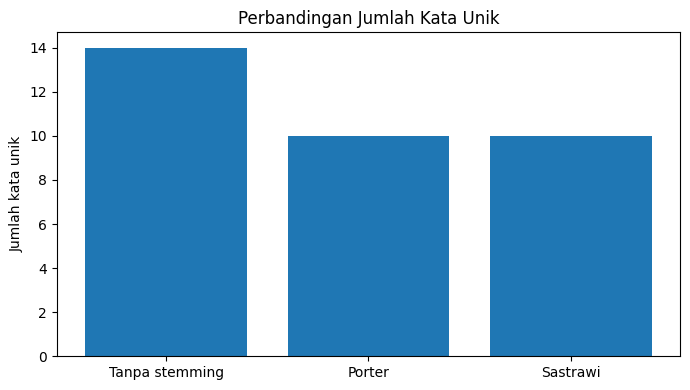

In [9]:
# Buat korpus kecil untuk demo dampak stemming
docs = [
    'running runs runner easily',
    'researchers researched researching research',
    'pelayanan melayani dilayani pelayanan',
    'pendaftaran mendaftar didaftarkan pendaftaran'
]

all_words = []
all_porter = []
all_sastrawi = []

for d in docs:
    w = [x.lower() for x in word_tokenize(d) if re.match(r'^[A-Za-z]+$', x)]
    all_words.extend(w)
    all_porter.extend([porter.stem(x) for x in w])
    all_sastrawi.extend([stemmer_id.stem(x) for x in w])

unique_stats = pd.DataFrame({
    'metode': ['Tanpa stemming', 'Porter', 'Sastrawi'],
    'jumlah_kata_unik': [len(set(all_words)), len(set(all_porter)), len(set(all_sastrawi))]
})

display(unique_stats)

plt.figure(figsize=(7, 4))
plt.bar(unique_stats['metode'], unique_stats['jumlah_kata_unik'])
plt.title('Perbandingan Jumlah Kata Unik')
plt.ylabel('Jumlah kata unik')
plt.tight_layout()
plt.show()

## 4) Fungsi Reusable: `stem_text`

Agar praktis, kita buat fungsi stemming yang bisa dipakai ulang.

In [10]:
def stem_text(text, lang='id', method='sastrawi'):
    tokens = [t for t in word_tokenize(text) if re.match(r'^[A-Za-z]+$', t)]
    tokens = [t.lower() for t in tokens]

    if lang == 'id' and method == 'sastrawi':
        stemmed = [stemmer_id.stem(t) for t in tokens]
    elif lang == 'en' and method == 'porter':
        stemmed = [porter.stem(t) for t in tokens]
    elif lang == 'en' and method == 'lancaster':
        stemmed = [lancaster.stem(t) for t in tokens]
    else:
        raise ValueError("Kombinasi lang/method belum didukung.")

    return stemmed

sample_id = 'Petugas sedang memperbaiki pelayanan pendaftaran pasien.'
sample_en = 'Students were studying and studies were completed quickly.'

print('Contoh Indonesia (Sastrawi):')
print(stem_text(sample_id, lang='id', method='sastrawi'))

print('\nContoh Inggris (Porter):')
print(stem_text(sample_en, lang='en', method='porter'))

print('\nContoh Inggris (Lancaster):')
print(stem_text(sample_en, lang='en', method='lancaster'))

Contoh Indonesia (Sastrawi):
['tugas', 'sedang', 'baik', 'layan', 'daftar', 'pasien']

Contoh Inggris (Porter):
['student', 'were', 'studi', 'and', 'studi', 'were', 'complet', 'quickli']

Contoh Inggris (Lancaster):
['stud', 'wer', 'study', 'and', 'study', 'wer', 'complet', 'quick']


---
## ✅ Kesimpulan

- Porter dan Lancaster sama-sama untuk bahasa Inggris, dengan Lancaster cenderung lebih agresif.
- Sastrawi lebih tepat untuk stemming bahasa Indonesia.
- Stemming membantu mengurangi variasi kata, sehingga fitur teks lebih ringkas.

Langkah lanjutan yang disarankan:
1. Kombinasikan stemming + stopword removal
2. Bandingkan dengan lemmatization
3. Gunakan hasil stemming untuk TF-IDF atau klasifikasi sentimen